In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import scienceplots

plt.style.use(["science","notebook"])

In [24]:
def compute_IGs(imbalances, correction=True):    
    n_indep_realizations = imbalances.shape[0]
    n_taus = imbalances.shape[1]
    
    IGs_vs_alpha = 100*(imbalances[:,:,0,np.newaxis]-imbalances) / imbalances[:,:,0,np.newaxis]
    alphas_max = np.argmax(IGs_vs_alpha.mean(axis=0), axis=-1)

    IGs = IGs_vs_alpha.mean(axis=0)[np.arange(n_taus),alphas_max]
    errors = IGs_vs_alpha.std(axis=0)[np.arange(n_taus),alphas_max] / np.sqrt(n_indep_realizations)

    if correction:
        IGs[imbalances[:,:,0].mean(axis=0) > 1] = 0
        errors[imbalances[:,:,0].mean(axis=0) > 1] = 0
        
    return IGs, errors

In [ ]:
t0 = 1
tau_e = 1
E = 4
ciao = np.arange(t0-tau_e*(E-1),t0+tau_e,tau_e)

### Surprisal -> fmri

In [26]:
# parameters
k = 25
E_X = 3
E_Y = 3
tau_e = 1
alphas = np.linspace(0,1.5,100)
taus = np.arange(0,20)

# read data
brain_data_part = pickle.load(open("./data/brain_data_part.pkl","rb"))
sfl_gpt2 = pickle.load(open("./data/sfl_gpt2.pkl","rb"))

participants = np.array(list(brain_data_part['all'].keys()))
areas = np.array(list(brain_data_part.keys()))

imbs_X_to_Y = np.zeros((len(participants),len(areas),len(taus),len(alphas)))
imbs_Y_to_X = np.zeros((len(participants),len(areas),len(taus),len(alphas)))
for i_area, area in enumerate(areas):
    for j_part, part in enumerate(participants):
        _, _, imbs_X_to_Y[i_area,j_part], imbs_Y_to_X[i_area,j_part] = (
            pickle.load(open(f"./pickles_s/part{part}_area{area}_EX{E_X}_EY{E_Y}_taue{tau_e}_k{k}.p","rb"))
        )

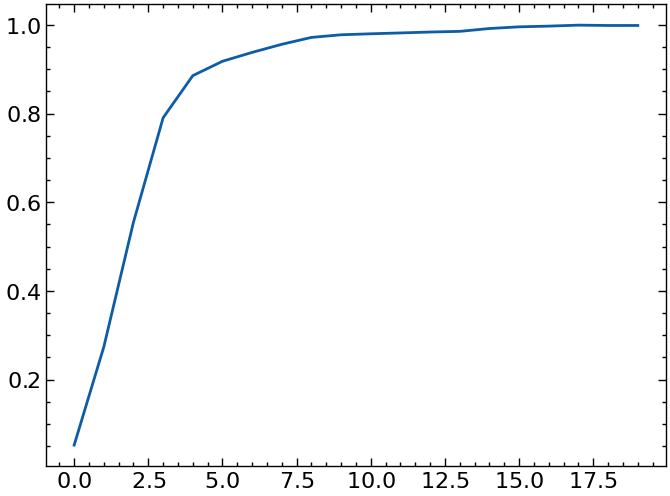

In [27]:
plt.plot(imbs_Y_to_X[:,0,:,0].mean(axis=0))

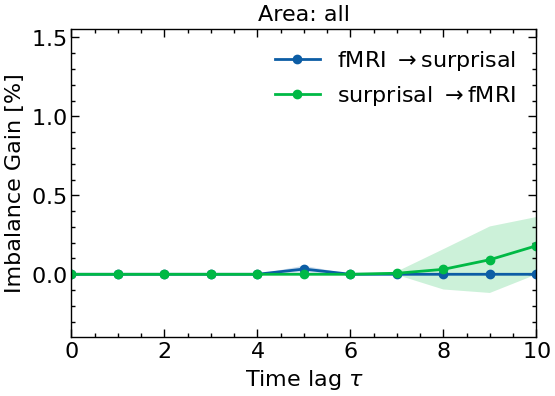

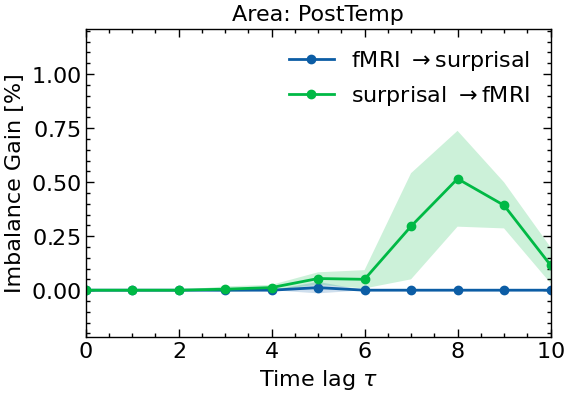

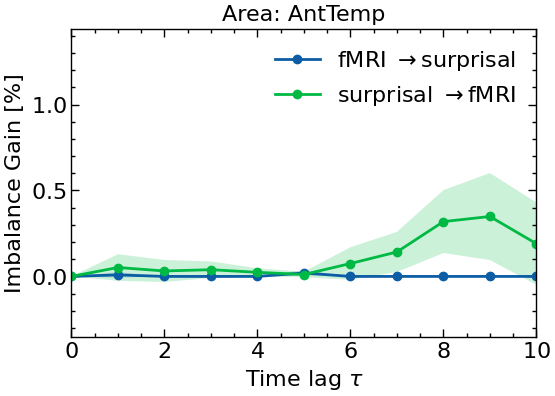

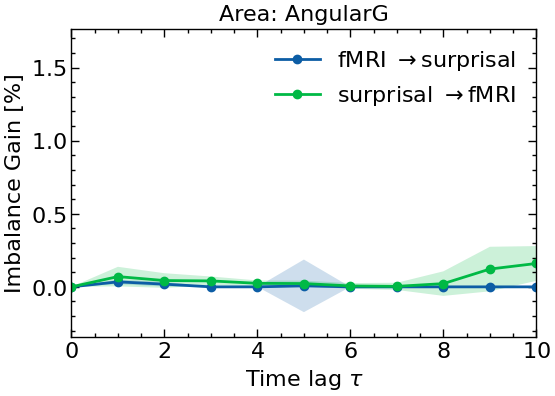

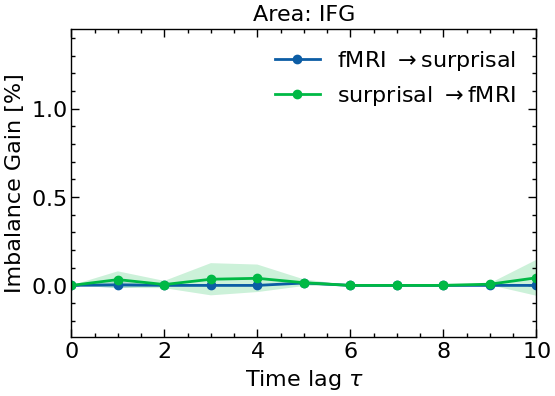

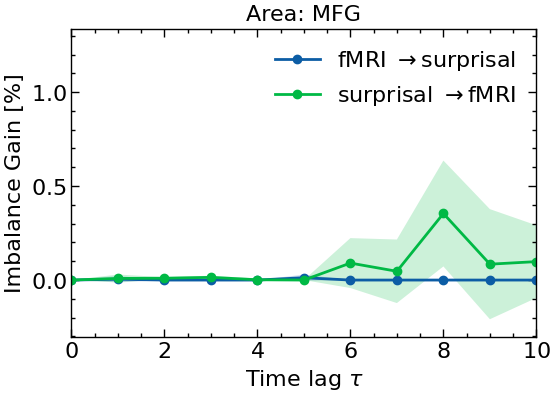

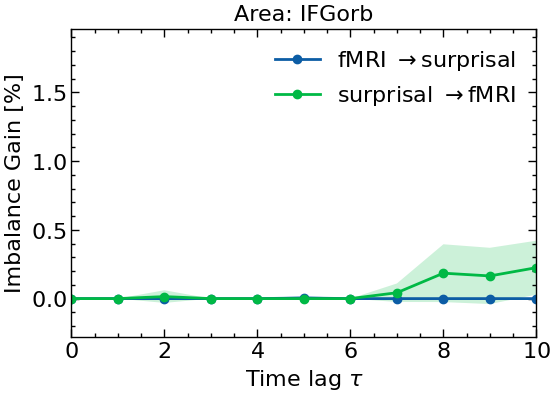

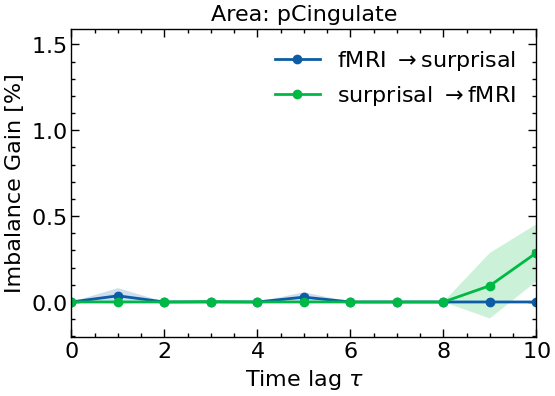

In [28]:
for i_area, area in enumerate(areas):
    IGs_X_to_Y, errors_X_to_Y = compute_IGs(imbs_X_to_Y[i_area])
    IGs_Y_to_X, errors_Y_to_X = compute_IGs(imbs_Y_to_X[i_area])

    plt.figure(figsize=(6,4))
    plt.plot(taus, IGs_X_to_Y, 'o-', label="fMRI $\\rightarrow $surprisal")
    plt.plot(taus, IGs_Y_to_X, 'o-', label="surprisal $\\rightarrow $fMRI")
    plt.fill_between(taus, IGs_X_to_Y-errors_X_to_Y, IGs_X_to_Y+errors_X_to_Y, alpha=0.2)
    plt.fill_between(taus, IGs_Y_to_X-errors_Y_to_X, IGs_Y_to_X+errors_Y_to_X, alpha=0.2)
    plt.xlabel("Time lag $\\tau$")
    plt.ylabel("Imbalance Gain [%]")
    plt.title(f"Area: {area}")
    plt.legend()
    plt.xlim([0,10])
    #plt.savefig(f"./figures/surprisal_vs_fmri_{area}.pdf", dpi=300)
    plt.show()

### log(frequency) -> fmri

In [34]:
# parameters
k = 25
E_X = 3
E_Y = 3
tau_e = 1
alphas = np.linspace(0,1.5,100)
taus = np.arange(0,20)

# read data
brain_data_part = pickle.load(open("./data/brain_data_part.pkl","rb"))
sfl_gpt2 = pickle.load(open("./data/sfl_gpt2.pkl","rb"))

participants = np.array(list(brain_data_part['all'].keys()))
areas = np.array(list(brain_data_part.keys()))

imbs_X_to_Y = np.zeros((len(participants),len(areas),len(taus),len(alphas)))
imbs_Y_to_X = np.zeros((len(participants),len(areas),len(taus),len(alphas)))
for i_area, area in enumerate(areas):
    for j_part, part in enumerate(participants):
        _, _, imbs_X_to_Y[i_area,j_part], imbs_Y_to_X[i_area,j_part] = (
            pickle.load(open(f"./pickles_f/part{part}_area{area}_EX{E_X}_EY{E_Y}_taue{tau_e}_k{k}.p","rb"))
        )

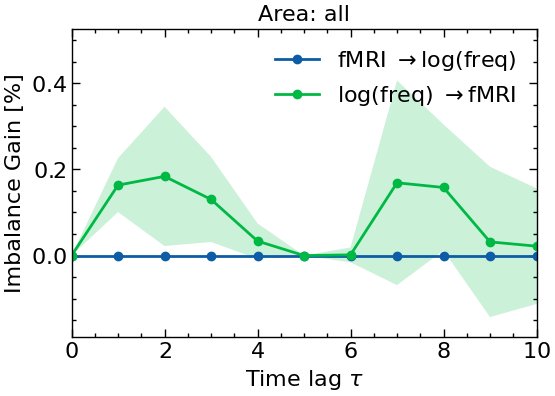

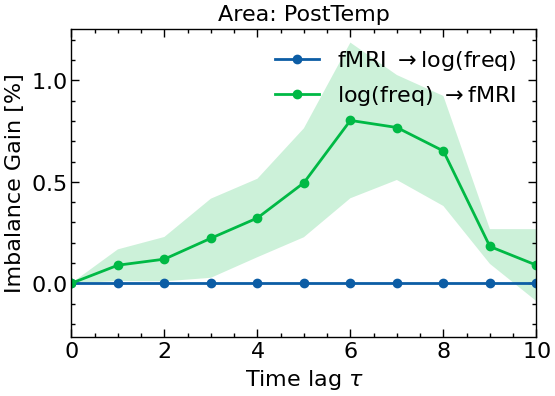

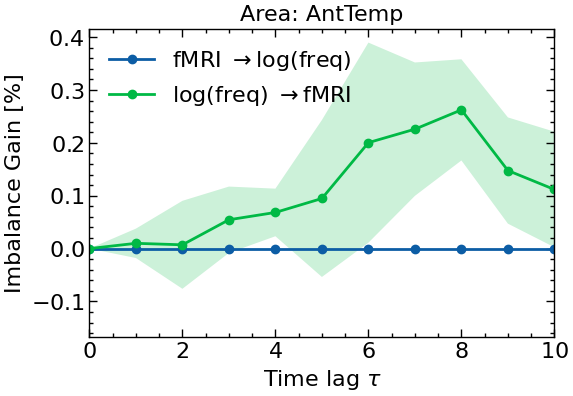

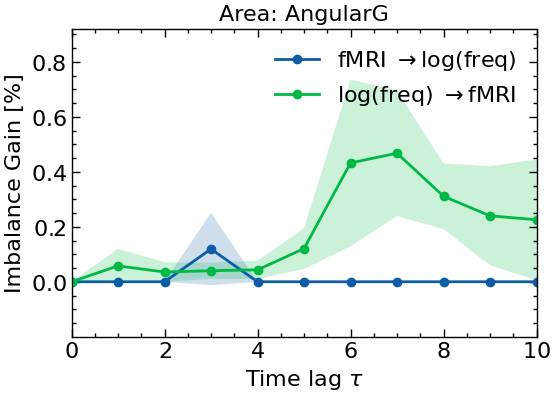

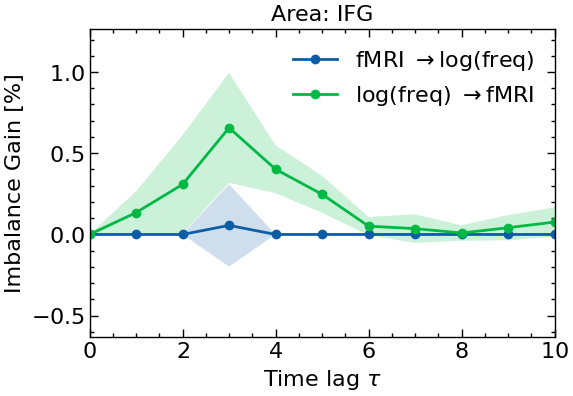

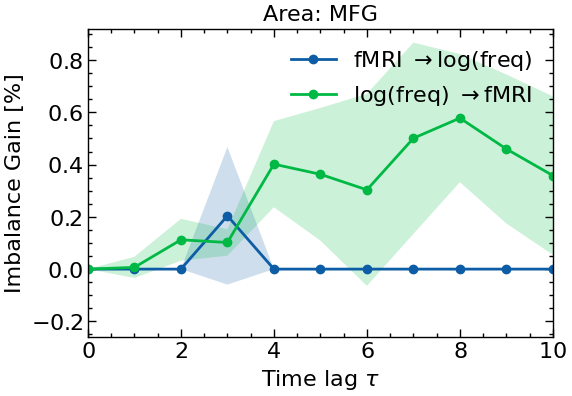

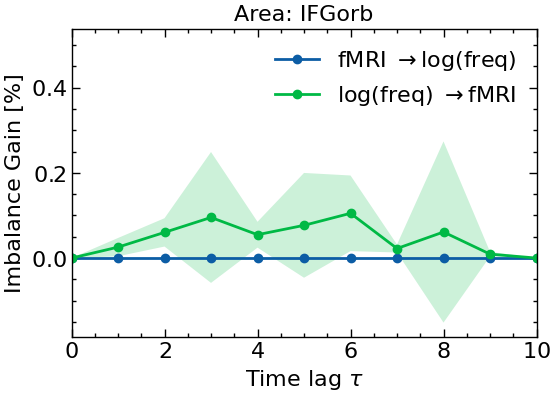

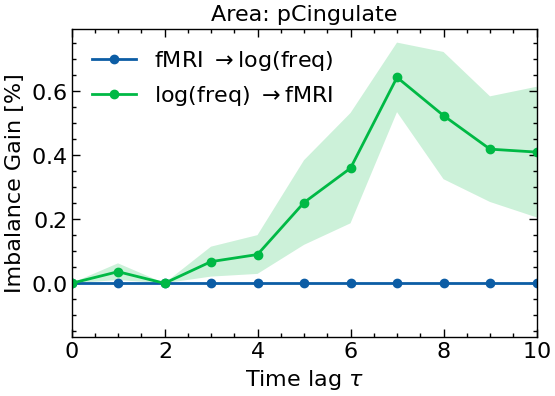

In [35]:
for i_area, area in enumerate(areas):
    IGs_X_to_Y, errors_X_to_Y = compute_IGs(imbs_X_to_Y[i_area])
    IGs_Y_to_X, errors_Y_to_X = compute_IGs(imbs_Y_to_X[i_area])

    plt.figure(figsize=(6,4))
    plt.plot(taus, IGs_X_to_Y, 'o-', label="fMRI $\\rightarrow $log(freq)")
    plt.plot(taus, IGs_Y_to_X, 'o-', label="log(freq) $\\rightarrow $fMRI")
    plt.fill_between(taus, IGs_X_to_Y-errors_X_to_Y, IGs_X_to_Y+errors_X_to_Y, alpha=0.2)
    plt.fill_between(taus, IGs_Y_to_X-errors_Y_to_X, IGs_Y_to_X+errors_Y_to_X, alpha=0.2)
    plt.xlabel("Time lag $\\tau$")
    plt.ylabel("Imbalance Gain [%]")
    plt.title(f"Area: {area}")
    plt.legend()
    plt.xlim([0,10])
    #plt.savefig(f"./figures/freq_vs_fmri_{area}.pdf", dpi=300)
    plt.show()

### length -> fmri

In [31]:
# parameters
k = 25
E_X = 3
E_Y = 3
tau_e = 1
alphas = np.linspace(0,1.5,100)
taus = np.arange(0,20)

# read data
brain_data_part = pickle.load(open("./data/brain_data_part.pkl","rb"))
sfl_gpt2 = pickle.load(open("./data/sfl_gpt2.pkl","rb"))

participants = np.array(list(brain_data_part['all'].keys()))
areas = np.array(list(brain_data_part.keys()))

imbs_X_to_Y = np.zeros((len(participants),len(areas),len(taus),len(alphas)))
imbs_Y_to_X = np.zeros((len(participants),len(areas),len(taus),len(alphas)))
for i_area, area in enumerate(areas):
    for j_part, part in enumerate(participants):
        _, _, imbs_X_to_Y[i_area,j_part], imbs_Y_to_X[i_area,j_part] = (
            pickle.load(open(f"./pickles_l/part{part}_area{area}_EX{E_X}_EY{E_Y}_taue{tau_e}_k{k}.p","rb"))
        )

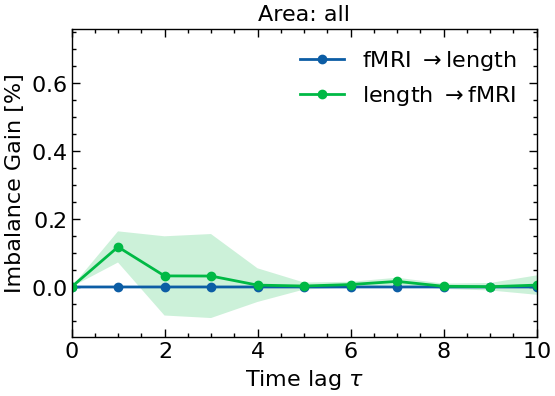

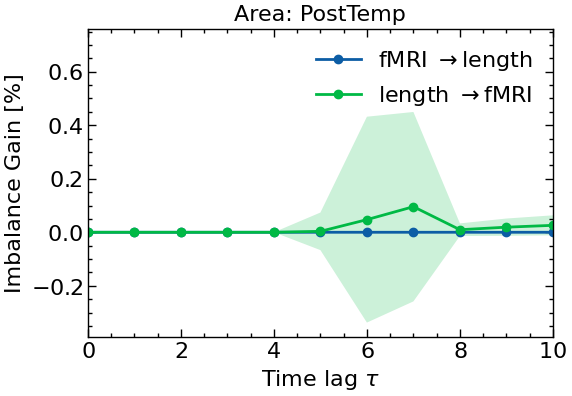

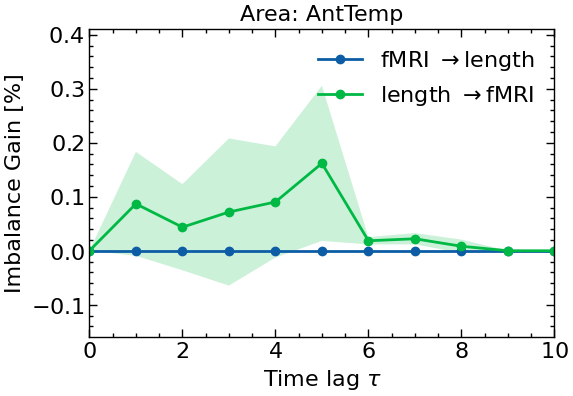

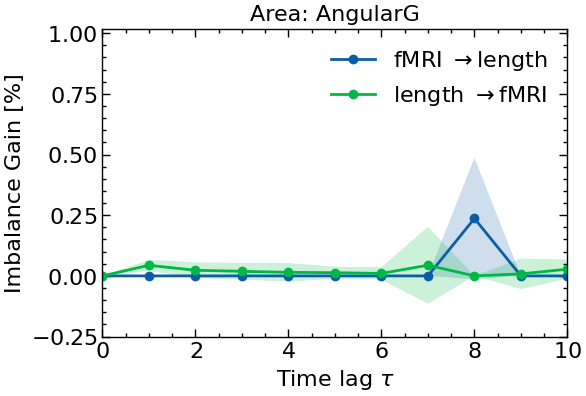

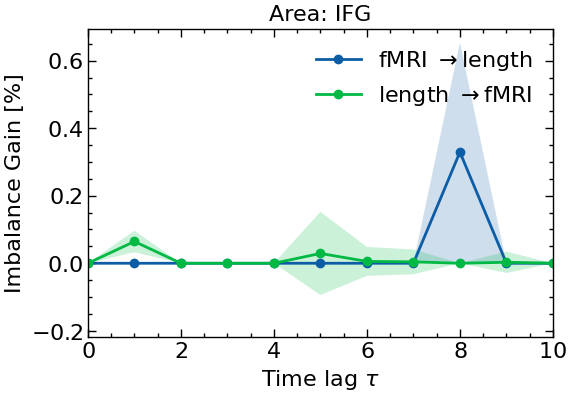

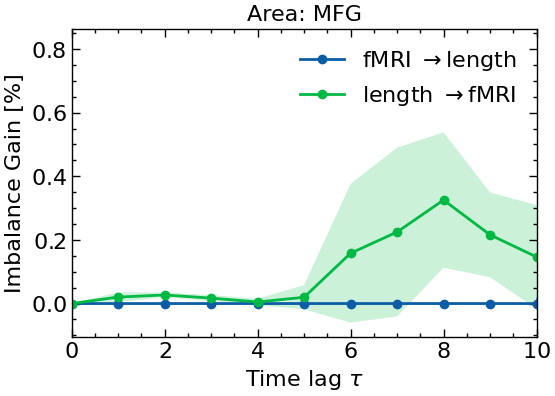

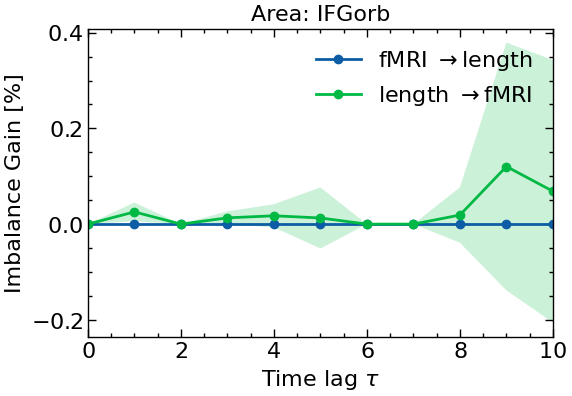

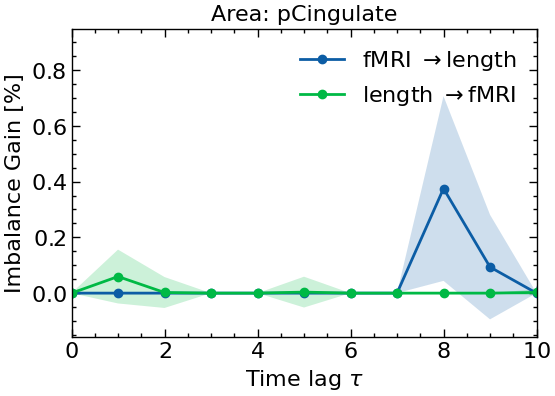

In [33]:
for i_area, area in enumerate(areas):
    IGs_X_to_Y, errors_X_to_Y = compute_IGs(imbs_X_to_Y[i_area])
    IGs_Y_to_X, errors_Y_to_X = compute_IGs(imbs_Y_to_X[i_area])

    plt.figure(figsize=(6,4))
    plt.plot(taus, IGs_X_to_Y, 'o-', label="fMRI $\\rightarrow $length")
    plt.plot(taus, IGs_Y_to_X, 'o-', label="length $\\rightarrow $fMRI")
    plt.fill_between(taus, IGs_X_to_Y-errors_X_to_Y, IGs_X_to_Y+errors_X_to_Y, alpha=0.2)
    plt.fill_between(taus, IGs_Y_to_X-errors_Y_to_X, IGs_Y_to_X+errors_Y_to_X, alpha=0.2)
    plt.xlabel("Time lag $\\tau$")
    plt.ylabel("Imbalance Gain [%]")
    plt.title(f"Area: {area}")
    plt.legend()
    plt.xlim([0,10])
    #plt.savefig(f"./figures/length_vs_fmri_{area}.pdf", dpi=300)
    plt.show()